In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
## The Normal Equations

In [83]:
W=np.linalg.inv(X_with_b.T@X_with_b)@X_with_b.T@Y
h= X_with_b@W
eror=(h-Y) 
cost= (1/(2*m))*(eror)@(eror)
cost, W

(np.float64(1.0175674588626875e-24),
 array([ 5.00000000e+00,  5.00000000e+00, -4.97379915e-14]))

In [6]:
## butch gradient descent

In [13]:
def gradient_descent(X_with_b, Y, learning_rate=0.01, epochs=1000):
    num_features = X_with_b.shape[1]
    W = np.zeros(num_features)
    
    cost_history = []
    W_history = [W.copy()]
    for epoch in range(epochs):
        h = X_with_b @ W
        error = h - Y
        
        cost = (1 / (2 * m)) * (error @ error)
        cost_history.append(cost)
        W_history.append(W.copy())
        Gradient = (1 / m) * (X_with_b.T @ error)
        W = W - learning_rate * Gradient
        
    return W, cost_history ,W_history

In [14]:
df = pd.read_csv('train.csv')
X = df['x'].values.reshape(-1, 1)
Y=df['y']
m = Y.shape[0]
ones_column = np.ones((m, 1))
X_with_b = np.hstack((ones_column, X))

In [15]:
final_W, cost_history, W_history = gradient_descent(X_with_b, Y, learning_rate=0.0001, epochs=1000)

print("Final Weights:", final_W ,)

Final Weights: [0.01445103 0.99989447]


In [16]:
print("Shape of X_with_b:", X_with_b.shape)
print("Shape of W:", final_W.shape)

Shape of X_with_b: (1000000, 2)
Shape of W: (2,)


In [17]:
h_final = X_with_b @ final_W
mse = np.mean((h_final - Y) ** 2) 
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")
ss_res = np.sum((Y - h_final) ** 2) 
ss_tot = np.sum((Y - np.mean(Y)) ** 2) 

r2 = 1 - (ss_res / ss_tot)
print(f"R-squared: {r2:.4f} (which is {r2 * 100:.2f}%)")

RMSE: 3.00
R-squared: 0.9895 (which is 98.95%)


In [18]:
df_test = pd.read_csv('test.csv').dropna()

X_test = df_test['x'].values.reshape(-1, 1)
Y_test = df_test['y'].values

m_test = X_test.shape[0]
X_test_with_b = np.hstack((np.ones((m_test, 1)), X_test))

h_test = X_test_with_b @ final_W

mse_test = np.mean((h_test - Y_test) ** 2)
rmse_test = np.sqrt(mse_test)

ss_res_test = np.sum((Y_test - h_test) ** 2)
ss_tot_test = np.sum((Y_test - np.mean(Y_test)) ** 2)
r2_test = 1 - (ss_res_test / ss_tot_test)

print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test R-squared: {r2_test:.4f}")

Test RMSE: 3.00
Test R-squared: 0.9893


C:\Users\Yoav Witkon\PythonAnaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


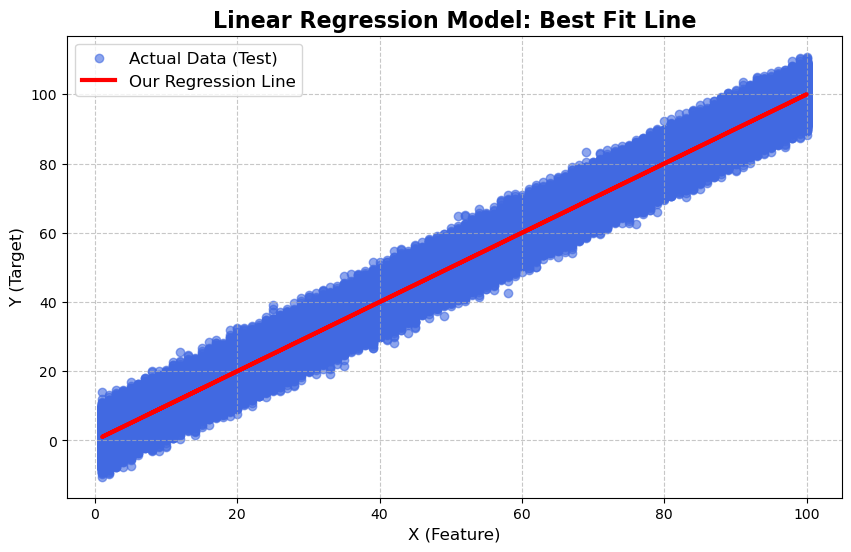

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(X_test, Y_test, color='royalblue', alpha=0.6, label='Actual Data (Test)')

plt.plot(X_test, h_test, color='red', linewidth=3, label='Our Regression Line')

plt.title('Linear Regression Model: Best Fit Line', fontsize=16, fontweight='bold')
plt.xlabel('X (Feature)', fontsize=12)
plt.ylabel('Y (Target)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()